# OLA 민원 사진 분류 CNN 학습 v3 (정확도 개선판)

v2(76.3%)에서 정확도를 더 올리기 위해 아래 항목을 바꾼 버전입니다.

**Part A — 직접 설계 CNN 개선 (모델 구조는 그대로, 데이터·학습 레시피만 개선)**

| 항목 | v2 | v3 | 이유 |
|---|---|---|---|
| 데이터 양 | 카테고리당 ~1,600장 | **카테고리당 최대 3,000장** (`prepare_dataset7_more_data.py`로 재크롭) | 처음부터 학습하는 CNN은 데이터 양이 정확도에 가장 큰 영향 |
| 입력 해상도 | 128 | **160** | 현수막 글자·도로 표시선 같은 세부 정보 보존 |
| 증강 | 회전/색상/이동 | **RandomResizedCrop + TrivialAugmentWide + RandomErasing** | 과적합(train 86% vs val 76% 격차) 완화 |
| 손실함수 | CrossEntropy | **+ Label Smoothing 0.1** | 과잉확신 방지 → 일반화 개선 |
| 옵티마이저 | Adam + ReduceLROnPlateau | **AdamW + Warmup + CosineAnnealing** | v2에서 val 곡선이 심하게 출렁였던 문제(7~8, 16 epoch 급락) 완화 |
| 에폭 | 30 고정 | **최대 60 + Early Stopping(patience 12)** | 개선 여지가 있으면 더 학습, 없으면 자동 중단 |

**Part B — 전이학습(ResNet18) 비교 실험**

같은 데이터·같은 분리 기준으로 사전학습 ResNet18을 파인튜닝해서, "직접 설계 vs 전이학습"을
공정하게 비교합니다.

In [ ]:
# 1) 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

import torch
print('PyTorch 버전:', torch.__version__)
print('GPU 사용 가능:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Mounted at /content/drive
PyTorch 버전: 2.11.0+cu128
GPU 사용 가능: True
GPU: Tesla T4


In [ ]:
# 2) 데이터셋 압축 해제 (한글 폴더명 깨짐 방지: CP949 지정)
ZIP_PATH = '/content/drive/MyDrive/ola_dataset_v3.zip'

!rm -rf /content/dataset
!mkdir -p /content/dataset
!unzip -O CP949 -q "$ZIP_PATH" -d /content/dataset

import os
DATA_DIR = '/content/dataset'
sub = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print('카테고리 폴더 목록:', sub)
for d in sub:
    n = len(os.listdir(os.path.join(DATA_DIR, d)))
    print(f'  {d}: {n:,}장')

카테고리 폴더 목록: ['보행방해물', '현수막', '불법주정차']
  보행방해물: 2,453장
  현수막: 3,000장
  불법주정차: 3,000장


In [ ]:
# 3) 하이퍼파라미터 (Part A: 직접 설계 CNN)
IMG_SIZE = 160        # 128 → 160 (세부 정보 보존, 연산량은 GAP 구조라 큰 부담 없음)
BATCH_SIZE = 32
EPOCHS = 60           # 30 → 최대 60 (early stopping이 알아서 멈춤)
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-2   # AdamW용 (decoupled weight decay라 Adam 때보다 크게 잡는 게 표준)
WARMUP_EPOCHS = 3     # 초반 3 epoch 동안 LR을 서서히 올림 (초기 발산 방지)
LABEL_SMOOTHING = 0.1
EARLY_STOP_PATIENCE = 12   # val 정확도가 12 epoch 동안 안 오르면 중단
VALIDATION_SPLIT = 0.2
SEED = 42

import random
import numpy as np
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [ ]:
# 4) 데이터 전처리 + 증강 (과적합 완화를 위해 증강을 크게 강화)
import torchvision
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    # 원본의 70~100% 영역을 무작위로 잘라 확대 → 위치/크기 변화에 강해짐
    # (크롭 이미지는 이미 객체 중심 정사각형이라 scale 하한을 0.7로 보수적으로 설정)
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), ratio=(0.9, 1.111)),
    transforms.RandomHorizontalFlip(),
    # TrivialAugmentWide: 회전/색상/대비/선명도 등 14가지 증강 중 매번 1개를
    # 무작위 강도로 적용. 하이퍼파라미터 튜닝 없이도 RandAugment급 효과.
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    # 이미지 일부를 무작위로 지움 → 특정 부분(예: 차 한 대)에만 의존하는 것 방지
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
# 5) Dataset / DataLoader 구성 (같은 영상은 절대 train/val에 나눠 담기지 않도록 그룹 단위 분리)
import os
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import GroupShuffleSplit

full_dataset = torchvision.datasets.ImageFolder(DATA_DIR)
class_names = full_dataset.classes
num_classes = len(class_names)
print('클래스:', class_names)

# prepare_dataset이 저장한 파일명 형식: "{영상ID}__{원본파일명}_{박스번호}.jpg"
def extract_group(path):
    filename = os.path.basename(path)
    if '__' in filename:
        return filename.split('__')[0]
    return filename

groups = [extract_group(path) for path, _ in full_dataset.samples]
print(f'전체 이미지 {len(groups)}장, 서로 다른 영상(그룹) {len(set(groups))}개')

splitter = GroupShuffleSplit(n_splits=1, test_size=VALIDATION_SPLIT, random_state=SEED)
train_idx, val_idx = next(splitter.split(X=range(len(groups)), groups=groups))

train_groups = set(groups[i] for i in train_idx)
val_groups = set(groups[i] for i in val_idx)
assert not (train_groups & val_groups), 'train/val에 같은 영상이 섞여 있습니다!'
print(f'학습 그룹(영상) {len(train_groups)}개 / 검증 그룹(영상) {len(val_groups)}개 → 겹치는 영상 없음 확인됨')

train_subset = Subset(full_dataset, train_idx)
val_subset = Subset(full_dataset, val_idx)

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return self.transform(image), label

# Part B(전이학습, 224 입력)에서도 "완전히 같은 분리"를 재사용하기 위한 헬퍼
def make_loaders(train_tf, val_tf, batch_size):
    tr = TransformedSubset(train_subset, train_tf)
    va = TransformedSubset(val_subset, val_tf)
    tr_loader = DataLoader(tr, batch_size=batch_size, shuffle=True,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va, batch_size=batch_size, shuffle=False,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    return tr_loader, va_loader

train_loader, val_loader = make_loaders(train_transform, val_transform, BATCH_SIZE)
print(f'학습 {len(train_idx)}장 / 검증 {len(val_idx)}장')

클래스: ['보행방해물', '불법주정차', '현수막']
전체 이미지 8453장, 서로 다른 영상(그룹) 1618개
학습 그룹(영상) 1294개 / 검증 그룹(영상) 324개 → 겹치는 영상 없음 확인됨
학습 6827장 / 검증 1626장


In [ ]:
# 6) 클래스 불균형 보정용 가중치 계산
from collections import Counter

train_labels = [full_dataset.samples[i][1] for i in train_subset.indices]
label_counts = Counter(train_labels)
print('학습셋 클래스별 개수:', {class_names[k]: v for k, v in label_counts.items()})

total = sum(label_counts.values())
class_weights = torch.tensor(
    [total / (num_classes * label_counts[i]) for i in range(num_classes)],
    dtype=torch.float32,
).to(device)
print('class_weights:', class_weights)

학습셋 클래스별 개수: {'보행방해물': 1858, '불법주정차': 2530, '현수막': 2439}
class_weights: tensor([1.2248, 0.8995, 0.9330], device='cuda:0')


## Part A — 직접 설계 CNN (v2와 같은 구조, 데이터·레시피만 개선)

모델 구조를 v2와 똑같이 유지하는 이유: "성능 향상이 순수하게 데이터·학습 방법
개선에서 왔다"는 걸 보여줄 수 있어서, 보고서의 기존 결론(모델보다 데이터가 중요)과
일관된 비교가 됩니다.

In [ ]:
# 7) CNN 모델 (v2와 동일한 구조)
import torch.nn as nn


class ConvBlock(nn.Module):
    """[Conv-BN-ReLU] x2 + MaxPool 한 단위"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x):
        return self.block(x)


class OlaComplaintCNN(nn.Module):
    """민원 사진 분류를 위해 직접 설계한 CNN (사전학습 가중치 없음)"""
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),     # 160 -> 80
            ConvBlock(32, 64),    # 80  -> 40
            ConvBlock(64, 128),   # 40  -> 20
            ConvBlock(128, 256),  # 20  -> 10
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)  # (256, 10, 10) -> (256, 1, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


model = OlaComplaintCNN(num_classes=num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'전체 파라미터: {total_params:,}')

전체 파라미터: 1,207,459


In [ ]:
# 8) 손실함수 / 옵티마이저 / 스케줄러 (★ v3에서 전부 교체)
# - Label Smoothing: 정답에 100% 확신하지 않도록 해 과적합 완화
# - AdamW: weight decay가 제대로 작동하는 Adam (Adam+wd는 L2가 어긋나게 적용됨)
# - Warmup + Cosine: v2에서 val 곡선이 크게 출렁였던 문제를 LR 관리로 완화
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=LEARNING_RATE * 0.01
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS]
)

In [ ]:
# 9) 학습/검증 한 epoch 처리 함수
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [ ]:
# 10) 실제 학습 루프 (early stopping 추가)
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
epochs_no_improve = 0
BEST_MODEL_PATH = '/content/best_model.pt'

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        marker = '  ← 최고 기록 갱신, 저장함'
    else:
        epochs_no_improve += 1

    lr_now = optimizer.param_groups[0]['lr']
    print(
        f'Epoch {epoch:2d}/{EPOCHS} | lr {lr_now:.2e} | '
        f'train_loss {train_loss:.4f} acc {train_acc:.3f} | '
        f'val_loss {val_loss:.4f} acc {val_acc:.3f}{marker}'
    )

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nval 정확도가 {EARLY_STOP_PATIENCE} epoch 동안 개선되지 않아 조기 종료합니다.')
        break

print(f'\n[직접 설계 CNN] 최고 검증 정확도: {best_val_acc:.3f}')

Epoch  1/60 | lr 4.00e-04 | train_loss 1.0452 acc 0.494 | val_loss 0.9535 acc 0.588  ← 최고 기록 갱신, 저장함
Epoch  2/60 | lr 7.00e-04 | train_loss 0.9904 acc 0.544 | val_loss 1.0436 acc 0.487
Epoch  3/60 | lr 1.00e-03 | train_loss 0.9441 acc 0.588 | val_loss 1.0943 acc 0.510
Epoch  4/60 | lr 9.99e-04 | train_loss 0.9125 acc 0.614 | val_loss 0.9114 acc 0.624  ← 최고 기록 갱신, 저장함
Epoch  5/60 | lr 9.97e-04 | train_loss 0.8935 acc 0.632 | val_loss 0.8109 acc 0.686  ← 최고 기록 갱신, 저장함
Epoch  6/60 | lr 9.93e-04 | train_loss 0.8607 acc 0.653 | val_loss 0.7937 acc 0.692  ← 최고 기록 갱신, 저장함
Epoch  7/60 | lr 9.88e-04 | train_loss 0.8440 acc 0.675 | val_loss 0.7988 acc 0.710  ← 최고 기록 갱신, 저장함
Epoch  8/60 | lr 9.81e-04 | train_loss 0.8332 acc 0.678 | val_loss 0.7539 acc 0.715  ← 최고 기록 갱신, 저장함
Epoch  9/60 | lr 9.73e-04 | train_loss 0.8127 acc 0.695 | val_loss 0.7883 acc 0.684
Epoch 10/60 | lr 9.64e-04 | train_loss 0.7960 acc 0.703 | val_loss 0.8323 acc 0.692
Epoch 11/60 | lr 9.53e-04 | train_loss 0.7741 acc 0.723 | 

In [ ]:
# (그래프 한글 깨짐 방지) 나눔고딕 폰트 설치
!apt-get -qq install fonts-nanum > /dev/null

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False
print('한글 폰트 설정 완료')

한글 폰트 설정 완료


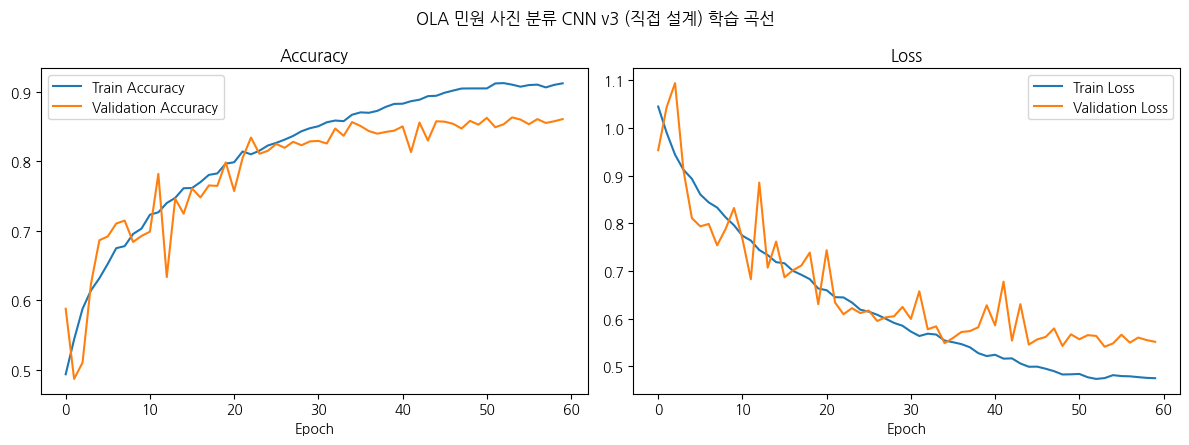

In [ ]:
# 11) 학습 곡선 (발표자료용)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history['train_acc'], label='Train Accuracy')
axes[0].plot(history['val_acc'], label='Validation Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_loss'], label='Train Loss')
axes[1].plot(history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('OLA 민원 사진 분류 CNN v3 (직접 설계) 학습 곡선')
plt.tight_layout()
plt.savefig('/content/training_curve_v3.png', dpi=150)
plt.show()

              precision    recall  f1-score   support

       보행방해물       0.85      0.83      0.84       595
       불법주정차       0.82      0.95      0.88       470
         현수막       0.92      0.83      0.87       561

    accuracy                           0.86      1626
   macro avg       0.86      0.87      0.86      1626
weighted avg       0.87      0.86      0.86      1626



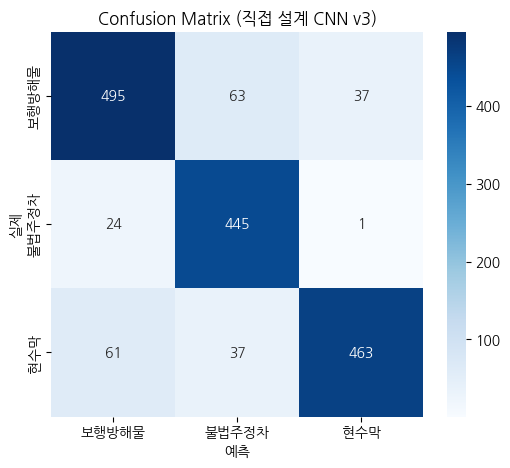

In [ ]:
# 12) 최고 가중치 불러와서 최종 평가 (Confusion Matrix + 리포트)
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))
scratch_report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('예측')
plt.ylabel('실제')
plt.title('Confusion Matrix (직접 설계 CNN v3)')
plt.savefig('/content/confusion_matrix_v3.png', dpi=150)
plt.show()

## Part B — 전이학습(ResNet18) 비교 실험

ImageNet 120만 장으로 사전학습된 ResNet18을 우리 데이터로 파인튜닝합니다.
**train/val 분리(영상 그룹 단위)를 Part A와 완전히 동일하게 재사용**하므로 공정한 비교입니다.

- 입력 224×224 (사전학습 당시 해상도와 맞춤)
- 백본(사전학습된 부분)은 작은 LR(1e-4), 새로 붙인 분류층은 큰 LR(1e-3)
- 이미 좋은 특징을 알고 있으므로 에폭은 15면 충분



In [ ]:
# 13) 전이학습용 데이터로더 (224 입력, 같은 분리 재사용)
TL_IMG_SIZE = 224
TL_BATCH_SIZE = 32
TL_EPOCHS = 15
TL_EARLY_STOP_PATIENCE = 5

tl_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(TL_IMG_SIZE, scale=(0.7, 1.0), ratio=(0.9, 1.111)),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])
tl_val_transform = transforms.Compose([
    transforms.Resize((TL_IMG_SIZE, TL_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tl_train_loader, tl_val_loader = make_loaders(tl_train_transform, tl_val_transform, TL_BATCH_SIZE)
print('전이학습용 로더 준비 완료 (분리 기준은 Part A와 동일)')

전이학습용 로더 준비 완료 (분리 기준은 Part A와 동일)


In [ ]:
# 14) ResNet18 불러오기 + 분류층 교체 + 파인튜닝 설정
from torchvision import models

model_tl = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_tl.fc = nn.Linear(model_tl.fc.in_features, num_classes)
model_tl = model_tl.to(device)

# model_tl = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
# model_tl.classifier[3] = nn.Linear(model_tl.classifier[3].in_features, num_classes)

# 백본은 조심스럽게(1e-4), 새로 붙인 분류층은 과감하게(1e-3) 학습
backbone_params = [p for name, p in model_tl.named_parameters() if not name.startswith('fc.')]
head_params = [p for name, p in model_tl.named_parameters() if name.startswith('fc.')]

tl_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
tl_optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 1e-4},
    {'params': head_params, 'lr': 1e-3},
], weight_decay=1e-4)
tl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(tl_optimizer, T_max=TL_EPOCHS)

print('ResNet18 파인튜닝 준비 완료 | 파라미터:', f"{sum(p.numel() for p in model_tl.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


ResNet18 파인튜닝 준비 완료 | 파라미터: 11,178,051


In [ ]:
# 15) 전이학습 학습 루프
tl_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_tl_val_acc = 0.0
tl_no_improve = 0
BEST_TL_MODEL_PATH = '/content/best_model_tl.pt'

for epoch in range(1, TL_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model_tl, tl_train_loader, tl_criterion, tl_optimizer)
    val_loss, val_acc = run_epoch(model_tl, tl_val_loader, tl_criterion, optimizer=None)
    tl_scheduler.step()

    tl_history['train_loss'].append(train_loss)
    tl_history['train_acc'].append(train_acc)
    tl_history['val_loss'].append(val_loss)
    tl_history['val_acc'].append(val_acc)

    marker = ''
    if val_acc > best_tl_val_acc:
        best_tl_val_acc = val_acc
        tl_no_improve = 0
        torch.save(model_tl.state_dict(), BEST_TL_MODEL_PATH)
        marker = '  ← 최고 기록 갱신, 저장함'
    else:
        tl_no_improve += 1

    print(
        f'Epoch {epoch:2d}/{TL_EPOCHS} | '
        f'train_loss {train_loss:.4f} acc {train_acc:.3f} | '
        f'val_loss {val_loss:.4f} acc {val_acc:.3f}{marker}'
    )

    if tl_no_improve >= TL_EARLY_STOP_PATIENCE:
        print(f'\nval 정확도가 {TL_EARLY_STOP_PATIENCE} epoch 동안 개선되지 않아 조기 종료합니다.')
        break

print(f'\n[전이학습 ResNet18] 최고 검증 정확도: {best_tl_val_acc:.3f}')

Epoch  1/15 | train_loss 0.6210 acc 0.827 | val_loss 0.4901 acc 0.903  ← 최고 기록 갱신, 저장함
Epoch  2/15 | train_loss 0.5069 acc 0.900 | val_loss 0.4849 acc 0.908  ← 최고 기록 갱신, 저장함
Epoch  3/15 | train_loss 0.4835 acc 0.911 | val_loss 0.5270 acc 0.897
Epoch  4/15 | train_loss 0.4518 acc 0.932 | val_loss 0.4532 acc 0.926  ← 최고 기록 갱신, 저장함
Epoch  5/15 | train_loss 0.4280 acc 0.944 | val_loss 0.4456 acc 0.924
Epoch  6/15 | train_loss 0.4145 acc 0.948 | val_loss 0.4461 acc 0.930  ← 최고 기록 갱신, 저장함
Epoch  7/15 | train_loss 0.4101 acc 0.952 | val_loss 0.4389 acc 0.929
Epoch  8/15 | train_loss 0.3970 acc 0.960 | val_loss 0.4422 acc 0.931  ← 최고 기록 갱신, 저장함
Epoch  9/15 | train_loss 0.3860 acc 0.966 | val_loss 0.4349 acc 0.931
Epoch 10/15 | train_loss 0.3819 acc 0.967 | val_loss 0.4432 acc 0.929
Epoch 11/15 | train_loss 0.3802 acc 0.965 | val_loss 0.4389 acc 0.928
Epoch 12/15 | train_loss 0.3701 acc 0.971 | val_loss 0.4407 acc 0.923
Epoch 13/15 | train_loss 0.3700 acc 0.972 | val_loss 0.4384 acc 0.926

val 

              precision    recall  f1-score   support

       보행방해물       0.94      0.90      0.92       595
       불법주정차       0.91      0.97      0.94       470
         현수막       0.94      0.93      0.93       561

    accuracy                           0.93      1626
   macro avg       0.93      0.93      0.93      1626
weighted avg       0.93      0.93      0.93      1626



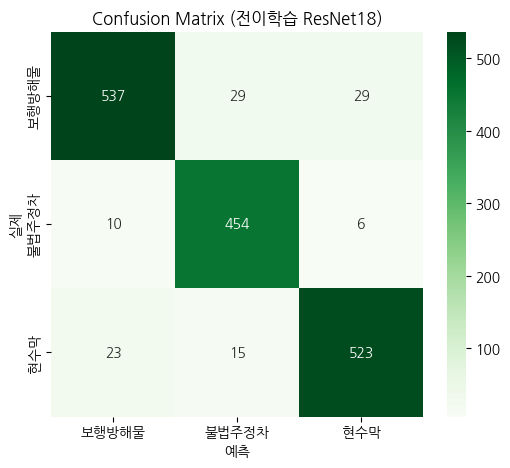

In [ ]:
# 16) 전이학습 최종 평가 (Confusion Matrix + 리포트)
model_tl.load_state_dict(torch.load(BEST_TL_MODEL_PATH))
model_tl.eval()

tl_y_true, tl_y_pred = [], []
with torch.no_grad():
    for images, labels in tl_val_loader:
        images = images.to(device)
        outputs = model_tl(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        tl_y_true.extend(labels.numpy())
        tl_y_pred.extend(preds)

print(classification_report(tl_y_true, tl_y_pred, target_names=class_names))

cm_tl = confusion_matrix(tl_y_true, tl_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('예측')
plt.ylabel('실제')
plt.title('Confusion Matrix (전이학습 ResNet18)')
plt.savefig('/content/confusion_matrix_tl.png', dpi=150)
plt.show()

In [ ]:
# 17) 두 모델 비교 요약 (보고서/발표용)
print('=' * 55)
print(f"{'모델':<28}{'최고 검증 정확도':>15}")
print('-' * 55)
print(f"{'직접 설계 CNN v2 (이전 기록)':<28}{'76.3%':>14}")
print(f"{'직접 설계 CNN v3 (이번)':<28}{best_val_acc:>13.1%}")
print(f"{'전이학습 ResNet18':<28}{best_tl_val_acc:>13.1%}")
print('=' * 55)
print()
print('웹페이지(complaint.html)에 올릴 최종 모델을 위 결과를 보고 선택하세요.')
print('아래 ONNX 내보내기 셀에서 EXPORT_TARGET만 바꾸면 됩니다.')

모델                                최고 검증 정확도
-------------------------------------------------------
직접 설계 CNN v2 (이전 기록)                 76.3%
직접 설계 CNN v3 (이번)                   86.3%
전이학습 ResNet18                       93.1%

웹페이지(complaint.html)에 올릴 최종 모델을 위 결과를 보고 선택하세요.
아래 ONNX 내보내기 셀에서 EXPORT_TARGET만 바꾸면 됩니다.


In [ ]:
# 18) 모델 + 클래스 목록을 구글 드라이브에 저장
import json

!cp /content/best_model.pt /content/drive/MyDrive/ola_complaint_model_v3.pt
!cp /content/best_model_tl.pt /content/drive/MyDrive/ola_complaint_model_resnet18.pt
!cp /content/training_curve_v3.png /content/drive/MyDrive/ 2>/dev/null
!cp /content/confusion_matrix_v3.png /content/drive/MyDrive/ 2>/dev/null
!cp /content/confusion_matrix_tl.png /content/drive/MyDrive/ 2>/dev/null

with open('/content/drive/MyDrive/ola_class_names.json', 'w', encoding='utf-8') as f:
    json.dump({
        'class_names': class_names,
        'img_size_scratch': IMG_SIZE,
        'img_size_transfer': TL_IMG_SIZE,
    }, f, ensure_ascii=False, indent=2)

print('저장 완료')
print(class_names)

저장 완료
['보행방해물', '불법주정차', '현수막']


## ONNX 내보내기 (브라우저 배포용)


In [ ]:
!pip install -q onnxscript onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 15.2 MB/s eta 0:00:00


In [ ]:
# 20) ONNX로 내보내기
EXPORT_TARGET = 'transfer'   # 'scratch' 또는 'transfer' — 정확도 높은 쪽 선택

if EXPORT_TARGET == 'scratch':
    export_model, export_size = model, IMG_SIZE
    model.load_state_dict(torch.load(BEST_MODEL_PATH))
else:
    export_model, export_size = model_tl, TL_IMG_SIZE
    model_tl.load_state_dict(torch.load(BEST_TL_MODEL_PATH))

export_model.eval()
dummy_input = torch.randn(1, 3, export_size, export_size).to(device)
torch.onnx.export(
    export_model,
    dummy_input,
    '/content/ola_complaint_model.onnx',
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12,
)
print(f'ONNX 변환 완료 ({EXPORT_TARGET}, 입력 {export_size}x{export_size})')

/tmp/ipykernel_672/492149586.py:13: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0714 02:27:37.549000 672 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX 변환 완료 (transfer, 입력 224x224)


In [ ]:
import onnx

m = onnx.load('/content/ola_complaint_model.onnx')
print('실제 opset:', [op.version for op in m.opset_import])
onnx.checker.check_model(m)
print('모델 구조 유효성 검사 통과')

실제 opset: [18]
모델 구조 유효성 검사 통과


In [ ]:
# external data 형식이면 단일 파일로 합치기 (기존 스크립트 그대로 사용)
!python fix_onnx_single_file.py \
    --in "/content/ola_complaint_model.onnx" \
    --out "/content/ola_complaint_model_single.onnx"

!cp /content/ola_complaint_model_single.onnx /content/drive/MyDrive/
print('드라이브에 저장 완료: ola_complaint_model_single.onnx')

python3: can't open file '/content/fix_onnx_single_file.py': [Errno 2] No such file or directory
cp: cannot stat '/content/ola_complaint_model_single.onnx': No such file or directory
드라이브에 저장 완료: ola_complaint_model_single.onnx
